SHAPE DATASET
(150, 5)


TIPE DATA
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


5 DATA PERTAMA
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


STATISTIK DESKRIPTIF
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350 

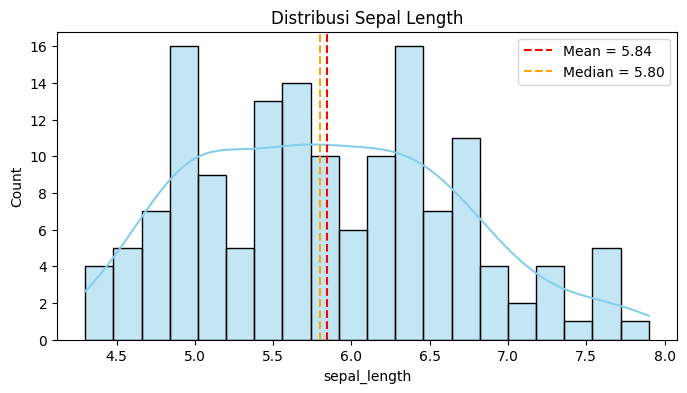

/tmp/ipykernel_3056/1359036148.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3056/1359036148.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


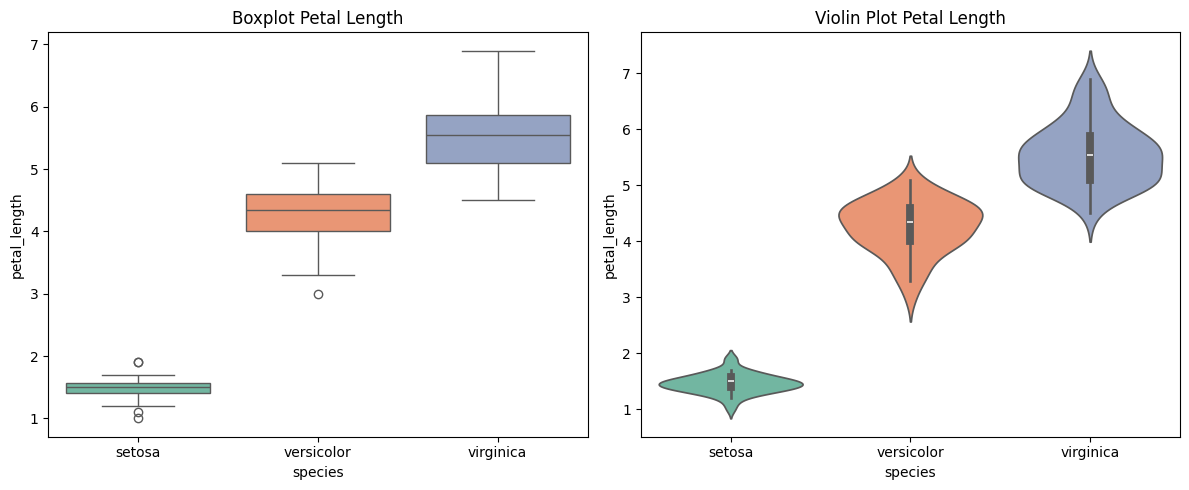



MATRIKS KORELASI PEARSON
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


KORELASI TERTINGGI
Pasangan Variabel : ('petal_width', 'petal_length')
Nilai Korelasi    : 0.963


KORELASI PEARSON & SPEARMAN
Pearson r  = 0.8718 (p = 0.000000)
Spearman ρ = 0.8819 (p = 0.000000)


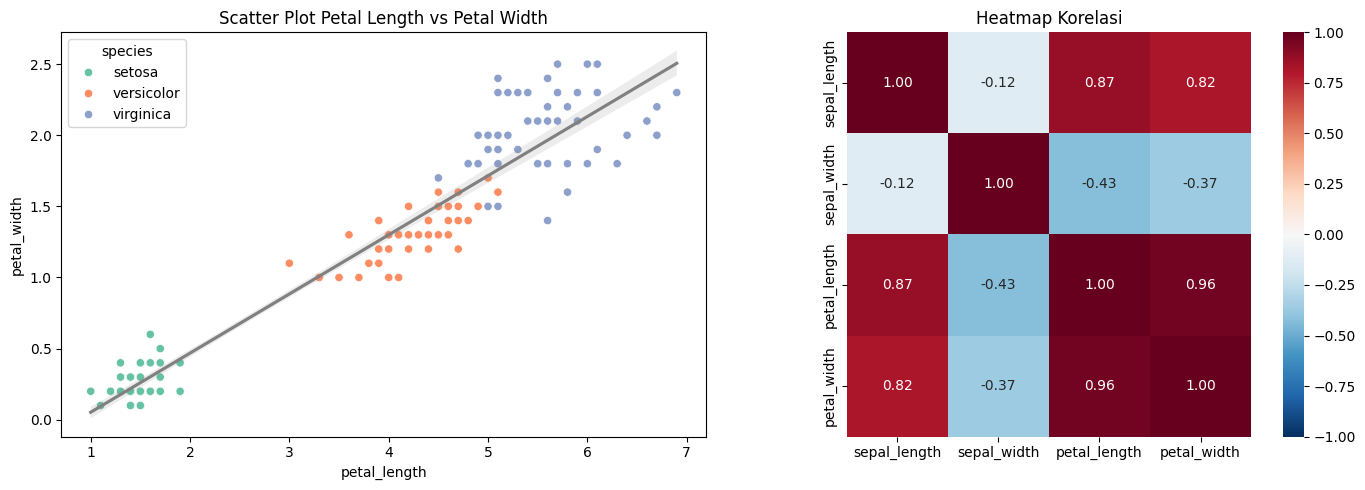



INTERPRETASI HASIL

1. Distribusi sepal_length mendekati normal karena
   mean dan median tidak berbeda jauh.

2. Petal_length dan petal_width memiliki
   korelasi positif sangat kuat.

3. Species virginica memiliki ukuran petal
   paling besar dibanding spesies lainnya.

4. Heatmap menunjukkan sebagian besar variabel
   memiliki hubungan positif.

5. Scatter plot menunjukkan tren linear positif
   antara petal_length dan petal_width.



In [13]:
# ============================================
# PRAKTIKUM PERTEMUAN 4
# STATISTIKA DASAR & ANALISIS DATA
# DATASET IRIS
# ============================================

# ============================================
# IMPORT LIBRARY
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================
# LOAD DATASET
# ============================================

df = sns.load_dataset('iris')

# ============================================
# INSPECT DATASET
# ============================================

print("="*50)
print("SHAPE DATASET")
print("="*50)

print(df.shape)

print("\n")

print("="*50)
print("TIPE DATA")
print("="*50)

print(df.dtypes)

print("\n")

print("="*50)
print("5 DATA PERTAMA")
print("="*50)

print(df.head())

print("\n")

print("="*50)
print("STATISTIK DESKRIPTIF")
print("="*50)

print(df.describe().round(3))

# ============================================
# STATISTIK DESKRIPTIF LENGKAP
# ============================================

print("\n")
print("="*50)
print("STATISTIK DESKRIPTIF LENGKAP")
print("="*50)

for col_name in df.select_dtypes(include='number').columns:

    col = df[col_name]

    print(f"\n=== {col_name} ===")

    print(f"Mean      : {col.mean():.3f}")
    print(f"Median    : {col.median():.3f}")
    print(f"Varians   : {col.var():.3f}")
    print(f"Std Dev   : {col.std():.3f}")
    print(f"Skewness  : {col.skew():.3f}")
    print(f"Kurtosis  : {col.kurt():.3f}")

# ============================================
# HISTOGRAM + KDE
# ============================================

fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    df['sepal_length'],
    kde=True,
    bins=20,
    color='skyblue',
    ax=ax
)

# Garis Mean
ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

# Garis Median
ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title("Distribusi Sepal Length")
ax.legend()

plt.show()

# ============================================
# BOXPLOT DAN VIOLIN PLOT
# ============================================

fig, axes = plt.subplots(1,2, figsize=(12,5))

# Boxplot
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title("Boxplot Petal Length")

# Violin Plot
sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    inner='box',
    ax=axes[1]
)

axes[1].set_title("Violin Plot Petal Length")

plt.tight_layout()
plt.show()

# ============================================
# KORELASI PEARSON
# ============================================

print("\n")
print("="*50)
print("MATRIKS KORELASI PEARSON")
print("="*50)

corr = df.drop('species', axis=1).corr(method='pearson')

print(corr.round(3))

# ============================================
# MENCARI KORELASI TERTINGGI
# ============================================

mask = np.triu(np.ones(corr.shape, dtype=bool))

corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()

print("\n")
print("="*50)
print("KORELASI TERTINGGI")
print("="*50)

print(f"Pasangan Variabel : {max_pair}")
print(f"Nilai Korelasi    : {corr.loc[max_pair]:.3f}")

# ============================================
# KORELASI PEARSON & SPEARMAN
# ============================================

x = df['sepal_length']
y = df['petal_length']

# Pearson
r, p_r = stats.pearsonr(x, y)

# Spearman
rho, p_s = stats.spearmanr(x, y)

print("\n")
print("="*50)
print("KORELASI PEARSON & SPEARMAN")
print("="*50)

print(f"Pearson r  = {r:.4f} (p = {p_r:.6f})")
print(f"Spearman ρ = {rho:.4f} (p = {p_s:.6f})")

# ============================================
# SCATTER PLOT & HEATMAP
# ============================================

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Scatter Plot
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

# Garis Regresi
sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title("Scatter Plot Petal Length vs Petal Width")

# Heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title("Heatmap Korelasi")

plt.tight_layout()
plt.show()

# ============================================
# INTERPRETASI HASIL
# ============================================

print("\n")
print("="*50)
print("INTERPRETASI HASIL")
print("="*50)

print("""
1. Distribusi sepal_length mendekati normal karena
   mean dan median tidak berbeda jauh.

2. Petal_length dan petal_width memiliki
   korelasi positif sangat kuat.

3. Species virginica memiliki ukuran petal
   paling besar dibanding spesies lainnya.

4. Heatmap menunjukkan sebagian besar variabel
   memiliki hubungan positif.

5. Scatter plot menunjukkan tren linear positif
   antara petal_length dan petal_width.
""")